In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
import os
import json
import sys
sys.path.append('../../utils')
from  configloader import Configloader
import cnn_helpers
from vit_helpers import ImageDataGeneratorFromDF, PatchEncoder, Patches, get_vit_configurations


2025-04-19 19:08:14.495738: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
CROP = True             #Based on notebook 3.2
PHASE = 'brand phase'

TRAIN_LIMIT = ['front']             #if you don't want to run the full 8 angle set of training, extend this list to train on other angles (one model output per angle-config combination!)

FLAT_TEST_SAMPLES_PER_BRAND = 2000


## System setup

In [3]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-04-19 19:08:16.397386: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 19:08:18.793331: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 19:08:18.793409: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [4]:
config = Configloader()

basedir = config.get('settings', 'image_directory')
augmdir = config.get('dir_augmentations', 'subfolder')
augmcsv = config.get('dir_augmentations', 'csv_dir')

vit_config = get_vit_configurations(
    os.path.join(
        config.get('directories', 'root_dir'), 
        config.get('settings', 'vit_configurations')
    )
)

augment_base = os.path.join(basedir, augmdir, PHASE)
augment_csv_dump = os.path.join(basedir, augmcsv, PHASE)

## Getting and preprocessing data

In [5]:
traindf = pd.read_csv(os.path.join(augment_csv_dump, 'traindata_brandphase.csv'))
testdf = pd.read_csv(os.path.join(augment_csv_dump, 'testdata_brandphase.csv'))

In [6]:
angles = traindf['model_label'].unique()

In [7]:
if 'TRAIN_LIMIT' in locals():
    angles = set(angles) & set(TRAIN_LIMIT)
    print('REDUCED TRAINING TASK ON ', len(angles), 'view(s)')
else:
    print('TRAINING ON FULL RANGE OF ANGLES')

REDUCED TRAINING TASK ON  1 view(s)


In [8]:
testdf = cnn_helpers.shuffle_df(testdf)
traindf = cnn_helpers.shuffle_df(traindf)

In [9]:
print(len(traindf))
print(len(testdf))

2400000
798122


## ViT training in a loop: 

In [10]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


def create_vit_classifier(input_shape, patchsize, imshape, output_classes, heads, vectorsize, transformer_layers, transfo_units, mlphead_units ):
    inputs = keras.Input(shape=input_shape)
    # Create patches.
    patches = Patches(patchsize)(inputs)
    # Encode patches.
    encoded_patches = PatchEncoder((imshape // patchsize) ** 2, vectorsize)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=heads, key_dim=vectorsize, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transfo_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, VECTORSIZE] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlphead_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(output_classes)(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model



def run_experiment_with_generators(model, filename, dir, lr, wd, traingen, valgen, maxepochs):

        # Path to the checkpoint
    checkpoint_dest_dir = os.path.join(dir, 'checkpoints')
    os.makedirs(checkpoint_dest_dir, exist_ok=True)
    checkpoint_name = filename.replace('.keras', '.weights.h5')  # otherwise you get an error
    checkpoint_filepath = os.path.join(checkpoint_dest_dir, checkpoint_name)

    # Resume from checkpoint if it exists
    if os.path.exists(checkpoint_filepath):
        print(f"Resuming training from checkpoint: {checkpoint_filepath}")
        model.load_weights(checkpoint_filepath)
    else:
        print("No checkpoint found. Starting training from scratch.")

    optimizer = keras.optimizers.AdamW(
        learning_rate=lr, weight_decay=wd
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )


    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    )

    # ReduceLROnPlateau callback: same as for CNN learners. 
    reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    # EarlyStopping callback
    early_stopping_callback = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )

    # Fit the model using generators
    history = model.fit(
        traingen,
        epochs=maxepochs,
        validation_data=valgen,
        callbacks=[checkpoint_callback, reduce_lr_callback, early_stopping_callback],
    )

    # Load the best model weights
    model.load_weights(checkpoint_filepath)

    # Final evaluation
    _, accuracy, top_5_accuracy = model.evaluate(valgen)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")
    
    #save the model:
    model.save(os.path.join(dir,filename))
    return history


In [11]:
model_dest_dir = os.path.join(
    config.get('directories', 'root_dir'), 
    config.get('directories', 'vit_dir')
)
os.makedirs(model_dest_dir, exist_ok=True)

Skipping ViT1-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT2-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT3-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT4-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT5-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT6-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT7-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT8-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT9-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT10-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT11-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT12-model_cropped=True_angle=front.keras -- model already trained
Skipping ViT13-model_cropped=True_angle=front.keras -- model already trained
Skipping

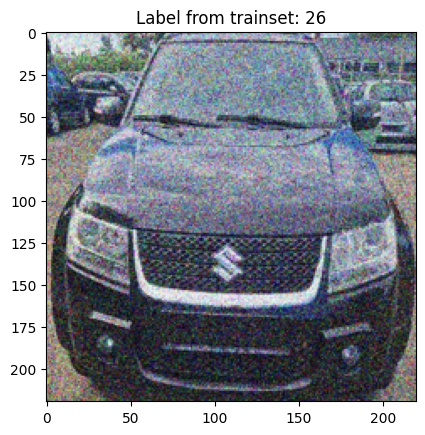

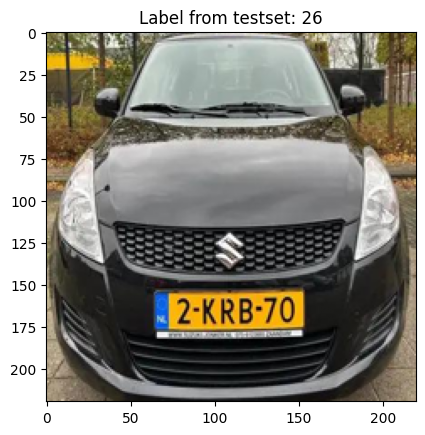

2025-04-19 19:08:32.188662: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 19:08:32.188824: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 19:08:32.188884: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 19:08:32.188976: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 19:08:32.189031: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

No checkpoint found. Starting training from scratch.


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4


I0000 00:00:1745082525.266844   14915 service.cc:146] XLA service 0x709d7001e1a0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745082525.266878   14915 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 6700 XT, AMDGPU ISA version: gfx1030
2025-04-19 19:08:45.633284: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


   1/9375 ━━━━━━━━━━━━━━━━━━━━ 94:52:03 36s/step - accuracy: 0.0625 - loss: 5.7034 - top-5-accuracy: 0.1875

I0000 00:00:1745082549.844919   14915 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9375/9375 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.0344 - loss: 3.4812 - top-5-accuracy: 0.1689
Epoch 1: val_accuracy improved from -inf to 0.15305, saving model to /home/frederic/Documents/automotive_project/models/vision_transformer/checkpoints/ViT26_max4-model_cropped=True_angle=front.weights.h5
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 1607s 167ms/step - accuracy: 0.0344 - loss: 3.4812 - top-5-accuracy: 0.1689 - val_accuracy: 0.1530 - val_loss: 3.0767 - val_top-5-accuracy: 0.4165 - learning_rate: 0.0010
Epoch 2/4
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.2813 - loss: 2.6155 - top-5-accuracy: 0.5641
Epoch 2: val_accuracy improved from 0.15305 to 0.48362, saving model to /home/frederic/Documents/automotive_project/models/vision_transformer/checkpoints/ViT26_max4-model_cropped=True_angle=front.weights.h5
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 1538s 164ms/step - accuracy: 0.2813 - loss: 2.6155 - top-5-accuracy: 0.5641 - val_accuracy: 0.4836 - val_loss: 2.1144 - val_top-5-accuracy

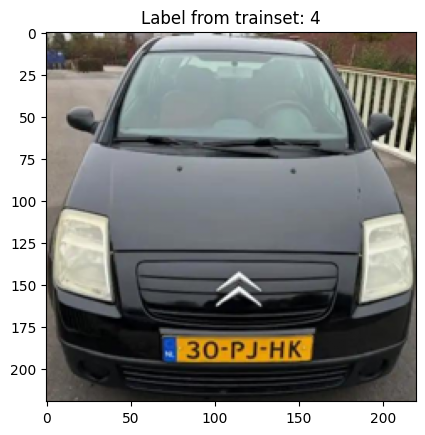

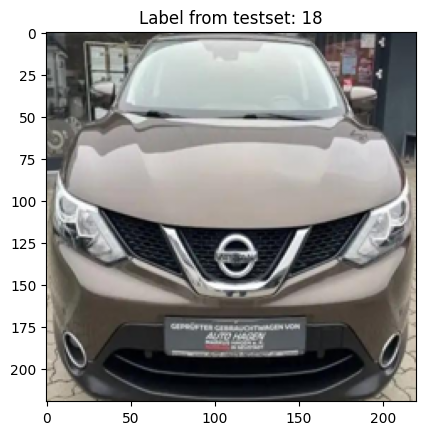

No checkpoint found. Starting training from scratch.


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.0336 - loss: 3.4801 - top-5-accuracy: 0.1645
Epoch 1: val_accuracy improved from -inf to 0.03335, saving model to /home/frederic/Documents/automotive_project/models/vision_transformer/checkpoints/ViT27_max4-model_cropped=True_angle=front.weights.h5
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 1568s 163ms/step - accuracy: 0.0336 - loss: 3.4801 - top-5-accuracy: 0.1645 - val_accuracy: 0.0334 - val_loss: 3.4020 - val_top-5-accuracy: 0.1666 - learning_rate: 5.0000e-04
Epoch 2/4
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.1104 - loss: 3.1696 - top-5-accuracy: 0.3019
Epoch 2: val_accuracy improved from 0.03335 to 0.47622, saving model to /home/frederic/Documents/automotive_project/models/vision_transformer/checkpoints/ViT27_max4-model_cropped=True_angle=front.weights.h5
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 1515s 162ms/step - accuracy: 0.1104 - loss: 3.1695 - top-5-accuracy: 0.3019 - val_accuracy: 0.4762 - val_loss: 1.9712 - val_

In [12]:
performances = []
for vit_name, settings in vit_config.items():
    ###################     READ THE SETTINGS FROM THE JSON CONFIG FILE FOR VIT TRAINING CONFIGRUATIONS 
    shape = settings['SHAPE']             # Size of the image on a single side in pixels
    patch_size = settings['PATCH_SIZE']         #Size of the patches to be extract from the input images(single dime), SHAPE%PATCH_SIZE should be 0
    batch_size = settings['BATCH_SIZE']        #how big ar teh batches for the learning part
    max_epochs = settings['MAX_EPOCHS']        #upper limit of epochs per learning task - there is early stopping and lr plateau just as in nobteook 2.

    learning_rate = settings['LEARNING_RATE']   
    weight_decay = settings['WEIGHT_DECAY']   
    transformer_layers = settings['TRANSFORMER_LAYERS']     #Should go up if amount of patches go up (let the model look for more relations between patches.)

    # 
    vectorsize = settings['VECTORSIZE']       ##64
    heads = settings['HEADS']      # 4

    mlpx = settings['MLP_X']
    mlpy = settings['MLP_Y']

    EXPLICIT = True            #render plots mid loop of patch generators?? True will show, anything else will not explicitly print out patches.
    testmode = settings['TINY']

    #####################   CHECK TO SEE IF THE CONFIGURATION LOADED IS VALID
    patches = (shape/patch_size)**2    #projected tokens required for transformer (no real need to mess with this)
    assert shape%patch_size == 0, f'Patch size of {patch_size} does not fit in Shape Size of {shape}!!'
    assert vectorsize % heads == 0, "PROJECTION_DIM SHOULD BE A MULTIPLE OF NUM_HEADS"


    transformer_units = [
        vectorsize * 2,
        vectorsize,
    ]  # Size of the transformer layers


    mlp_head_units = [
        mlpx,
        mlpy,
    ]  # Size of the dense layers of the final classifier

    input_shape = (shape, shape, 3) 


    #for TINY test
    if testmode:
        brands = ['ford', 'opel', 'bmw', 'renault']
        testdata = testdf[testdf['brand'].isin(brands)].copy()
        traindata = traindf[traindf['brand'].isin(brands)].copy()
    else:
        brands = testdf['brand'].unique()
        testdata = testdf.copy()
        traindata = traindf.copy()


    num_classes = len(brands) 
    label_encoder = LabelEncoder()
    label_encoder.fit(brands)
    #apply label encoding on train and test dataframes. 
    traindata['y_encoded'] = label_encoder.transform(traindata['brand'])
    testdata['y_encoded'] = label_encoder.transform(testdata['brand'])


    for angle in angles: 
        # Check if angle is trained already: 
        name = f'{vit_name}-model_cropped={CROP}_angle={angle}.keras'
        if name in os.listdir(model_dest_dir):
            print(f"Skipping {name} -- model already trained")
            continue

        view_by_angle_test = testdata.query('model_label==@angle').reset_index()
        view_by_angle_train = traindata.query('model_label==@angle').reset_index()

        #equalize testset; the moment you get out of testmode, the model collapses and predicts the dominant class.
        # you could have gone with macroF1 too, but then you have to implement it as an extra callback... much more work 
        view_by_angle_test_balanced = (
            view_by_angle_test.set_index('brand')
            .groupby(level=0, group_keys=False)
            .apply(lambda x: x.sample(n=1000, replace=True))
            .reset_index()
        )

        train_generator = ImageDataGeneratorFromDF(df=view_by_angle_train, 
                                                image_column='abs_path', 
                                                label_column='y_encoded', 
                                                batch_size=batch_size, 
                                                target_size=(shape, shape), 
                                                shuffle=True, 
                                                apply_crop=CROP)

        validation_generator = ImageDataGeneratorFromDF(df=view_by_angle_test_balanced, 
                                                        image_column='abs_path', 
                                                        label_column='y_encoded', 
                                                        batch_size=batch_size, 
                                                        target_size=(shape, shape), 
                                                        shuffle=True, 
                                                        apply_crop=CROP)
        
        #test the generators: trainview  #explicit truth/type check (think of PHP === vs ==) avoids EXPLICIT = 'no' issues.
        if EXPLICIT == True:    
            floored = len(view_by_angle_train) // batch_size
            images, labels = train_generator[np.random.randint(0,floored)]
            instance = np.random.randint(0, len(images))
            plt.imshow(images[instance])
            plt.title(f"Label from trainset: {labels[instance]}") 
            plt.show()

            #test the generators: testview
            floored = len(view_by_angle_test_balanced) // batch_size
            images, labels = validation_generator[np.random.randint(0,floored)]
            instance = np.random.randint(0, len(images))
            plt.imshow(images[instance])
            plt.title(f"Label from testset: {labels[instance]}") 
            plt.show()

        vit_classifier = create_vit_classifier(
                            input_shape,
                            patch_size, 
                            shape, 
                            num_classes, 
                            heads,
                            vectorsize, 
                            transformer_layers, 
                            transformer_units, 
                            mlp_head_units
                            )
        
        history = run_experiment_with_generators(
                            vit_classifier, 
                            name, 
                            model_dest_dir,
                            learning_rate, 
                            weight_decay, 
                            train_generator, 
                            validation_generator,
                            max_epochs
                            )
    
        performances.append(history)
    

In [13]:
view_by_angle_test.brand.value_counts()/len(view_by_angle_test)

brand
mercedes-benz    0.118593
volkswagen       0.113545
bmw              0.089566
audi             0.078464
ford             0.066397
opel             0.065905
renault          0.060159
peugeot          0.053756
skoda            0.034538
toyota           0.029838
citroen          0.029828
hyundai          0.025898
volvo            0.025416
fiat             0.025313
seat             0.023076
porsche          0.022769
nissan           0.021086
kia              0.021086
mini             0.018449
land-rover       0.015935
mazda            0.015073
dacia            0.014191
suzuki           0.009512
jeep             0.006505
honda            0.004915
alfa-romeo       0.004833
lexus            0.002411
subaru           0.002124
lotus            0.000462
alpine           0.000359
Name: count, dtype: float64

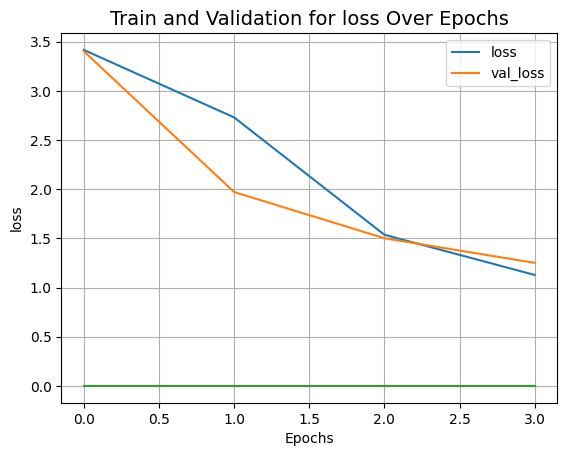

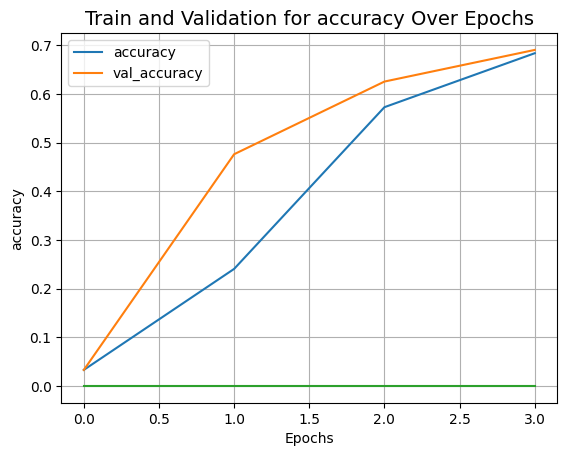

In [14]:
def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.plot(history.history['learning_rate'])
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation for {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_history("loss")
plot_history("accuracy")

Multiple ViT models where trained with variating hyperparameters; these models where trained on 3 classes in stead of 30 to reduce computation time. The performance of these models is compared in 3.5 BIS. Training these smaller ViT models was done by setting the `TESTMODE` constant to `true` and changing some of the hyperparameters. Below is a table with the hyperparameters per model and the observed performance in 3.5 BIS. Validationgenerator data also has baalnced classes here. Like this we can quickly see if the model improves from random guessing (1/len(brands)), without needing to take into account the heavy class imbalance that exists in this dataset. We do not use this in the final model that is not trained with `TESTMODE = False`; because of the heavy class imbalance. ViT 1 to 5 are self-configured attempts at setting up ViTs. ViT6 is based on Google's research paper: "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale" (2021) see: https://research.google/pubs/an-image-is-worth-16x16-words-transformers-for-image-recognition-at-scale/; they used the following settings: 
- Batch size:  4096
- Learning rate: varied
- heads: 12 - 16 (depending on VIT size)
- layer: 12 - 32 (depending on VIT dize)
- MLP size: 3072 - 5120 (depending on VIT size)
- Patch size: 16 - 32 
- Image size: 224
- weight decay: 0.1 (apparantly this can be done with AdamW)

It was trained on TPUv3 Hardware 

ChatGPT was fed this information and created a ViT6 configuration alternative that might fit the available hardware: 
- Radeon RX 6700XT (12GB)
- 96GB RAM DDR4 3600 CL16
- Ryzen 7 5800X (16 Core cpu)

Learning on the local system was done on GPU with ROCM (not the CPU). 

|HYPERPARAMETER|ViT1|ViT2|ViT3|ViT4|ViT5|ViT6
|--------------|----|----|----|----|----|---|
|SHAPE|224|224|224|224|224|224|
|PATCH_SIZE|28|28|16|16|28|16|
|BATCH_SIZE|128|128|64|64|128|64|
|LEARNING_RATE|0.001|0.001|0.001|0.001|0.001|0.0005|
|WEIGHT_DECAY|0.0001|0.0001|0.0001|0.0001|0.0001|0.01|
|TRANSFORMER_LAYERS|8|8|12|8|12|8|
|VECTORSIZE|64|128|128|128|128|512|
|HEADS|4|8|8|4|8|8|
|PATCHES (calculated value)|64|64|196|196|64|196|
||||||||
|Accuracy (3.5.bis)|||||||


There's a tradeoff: more patches and deeper layers have a bit better performance; but take much longer to train. VIT13 required 72 epochs and took 5h:23 to train; that's more than double the time it took to train ViT1; and the percentage of val_accuracy only went up by 1.5 percent. 

downsizing patches to 16 px; is not that great, I'd need more layers, but it crashes the computer - will try more variants on 28 px patches. 